# TSFresh-Features aus rohem, DPCA-, CVA- und ICA-gefiltertem TEP-Signal

Schwester-Notebook zu `TSFresh_PCA_DyCA.ipynb`: identische dreiphasige Pipeline
(Extraktion + Selektion auf Train, billige Test-Extraktion, LazyClassifier),
aber mit **DPCA**, **CVA** und **ICA** als Projektionen. `raw` läuft als
gemeinsamer Anker mit — dadurch sind die Ergebnisse beider Notebooks direkt
aneinander ausrichtbar.

## Die 16 Konfigurationen

| Konfiguration | Kanäle | Projektion |
|---|---|---|
| `raw` | 52 | keine — die 52 Prozessvariablen direkt |
| `dpca_4 … dpca_12` | 4, 6, 8, 10, 12 | DPCA pro Run: Scores der ersten *n* Hauptkomponenten der lag-erweiterten Matrix (L = 2, 156 Spalten) |
| `cva_4 … cva_12` | 4, 6, 8, 10, 12 | CVA pro Run: die ersten *n* kanonischen Variaten der Vergangenheit (p = f = 1) |
| `ica_4 … ica_12` | 4, 6, 8, 10, 12 | FastICA pro Run: *n* unabhängige Quellen, nach \|Exzess-Kurtosis\| absteigend geordnet |

Zusammen 52 + 40 + 40 + 40 = **172 Kanäle pro Run**. Die Parameter der
Verfahren (L, p/f, FastICA-Einstellungen) entsprechen den zugehörigen
Eigenwert-Notebooks `DPCA_Eigenwerte.ipynb` / `CVA_Eigenwerte.ipynb` /
`ICA_Eigenwerte.ipynb`.

## Kanallängen — kleine, dokumentierte Abweichung

Die Projektionen verkürzen die Zeitreihen methodisch bedingt unterschiedlich:
`raw`/`ica` behalten **480** Samples, `cva` hat **479** (der Zustand braucht
x_{t−1}), `dpca` hat **478** (L = 2 Lags). Das ist unkritisch, weil die
Regel „keine Längenartefakte" nur *innerhalb* einer Konfiguration greifen
muss: dort sind alle Runs und beide Splits exakt gleich lang. Zwischen
Konfigurationen werden Features nie verglichen — jede bekommt ihre eigene
Selektion und ihren eigenen Klassifizierer. `raw` bleibt bewusst bei 480,
damit die raw-Ergebnisse mit dem Schwester-Notebook bitidentisch sind und
der Cache geteilt werden kann (siehe unten).

## Gemeinsamer Cache mit `TSFresh_PCA_DyCA.ipynb`

`CACHE_DIR` ist absichtlich **derselbe** (`tsfresh_cache` bzw.
`tsfresh_cache_smoke`): die `raw`-Konfiguration ist in beiden Notebooks
bitidentisch (gleiche Vorverarbeitung, gleiche Länge, gleiches Chunking) —
vorhandene raw-Chunks und die raw-Top-`TOP_K`-Auswahl werden dadurch
**wiederverwendet**, was bei bereits gelaufenem Schwester-Notebook rund
5,5 h spart. Zwei Konsequenzen:

- **`CHUNK_RUNS` muss auf 250 bleiben** (Wert des Schwester-Notebooks) —
  sonst würden dessen Cache-Dateien mit falscher Chunk-Aufteilung
  interpretiert und Runs stumm verloren gehen.
- Die Ergebnis-CSV heißt hier `tsfresh_summary_dpca_cva_ica.csv`, damit
  `tsfresh_summary.csv` des Schwester-Notebooks nicht überschrieben wird.

Die Prefixe `dpca_*`, `cva_*`, `ica_*` kollidieren mit nichts Bestehendem.

## Vorgehen (dreistufig)

**Phase A — Extraktion + Selektion auf TRAIN.** Je Konfiguration werden alle
TSFresh-Features auf allen Trainingsruns berechnet (`EfficientFCParameters`,
~780 Features je Kanal), daraus per Relevanztabelle die besten `TOP_K`
ausgewählt. Danach wird die volle Matrix sofort verworfen.

**Phase B — Testset.** `from_columns()` übersetzt die ausgewählten
Featurenamen zurück in `kind_to_fc_parameters`; auf dem Testset werden nur
diese Features berechnet. Die Selektion sieht das Testset nie.

**Phase C — LazyClassifier** je Konfiguration, dann Vergleich über alle 16.

## Laufzeit und Speicher — bitte vor dem Start lesen

Maßstab aus dem vollständigen Lauf des Schwester-Notebooks (8 Kerne,
`EfficientFCParameters`, alle 500 Runs je Fault): ~6,5 min TSFresh-Zeit pro
Kanal in Phase A. Hier: `raw` aus dem Cache ≈ 0 h (sonst ~5,5 h), die 15
projizierten Konfigurationen ≈ 120 Kanäle → Phase A grob **13 h**, dazu die
FastICA-Fits (~0,1–0,3 s je Run und ica-Konfiguration) mit **~2 h** in
Phase A und nochmals ~2 h in Phase B. Phase B insgesamt ~3–4 h, Phase C
~30 min. Zusammen Größenordnung **17–22 h** bei vorhandenem raw-Cache.

Speicher ist unkritischer als im Schwester-Notebook: die größte neue
Konfiguration hat 12 Kanäle (~9 400 Features/Run); nur `raw` (40 404
Features/Run) bleibt groß — und kommt in der Regel aus dem Cache. Die
Mechanik (float32-Matrizen, Konfigurationen strikt nacheinander,
Relevanztests in Spaltenblöcken, Chunk-Cache) ist identisch.

**Der Cache macht den Lauf unterbrechbar.** Jeder Chunk landet als Pickle in
`CACHE_DIR`; ein Neustart überspringt alles bereits Berechnete.

> **`SMOKE_TEST` steht in der Konfigurationszelle.** Mit `True` läuft die
> komplette Pipeline in wenigen Minuten auf wenigen Runs durch. Für den
> echten Lauf auf `False` (am besten in tmux/über Nacht).

In [1]:
# ============================================================
# Imports
# ============================================================
import os
import gc
import json
import time
import warnings

import numpy as np
import pandas as pd

from scipy import stats

from sklearn.decomposition import PCA, FastICA
from sklearn.feature_selection import f_classif
from sklearn.metrics import balanced_accuracy_score, f1_score

from tsfresh import extract_features
from tsfresh.feature_extraction.settings import (
    MinimalFCParameters, EfficientFCParameters, ComprehensiveFCParameters,
    from_columns)
from tsfresh.feature_selection.relevance import calculate_relevance_table
from tsfresh.utilities.dataframe_functions import impute

from lazypredict.Supervised import LazyClassifier

try:
    from tqdm.auto import tqdm
    tqdm_available = True
except ImportError:
    tqdm_available = False

import tsfresh
print("tsfresh", tsfresh.__version__, "| pandas", pd.__version__,
      "| numpy", np.__version__, "| Kerne:", os.cpu_count())

tsfresh 0.21.2 | pandas 3.0.3 | numpy 2.4.6 | Kerne: 8


In [2]:
# ============================================================
# Konfiguration - die EINZIGE Stelle, an der geschraubt wird
# ============================================================

# SMOKE_TEST=True -> winziger Durchlauf (Minuten) zum Pruefen der Pipeline.
# Fuer den echten Lauf auf False setzen. Die Caches beider Modi liegen in
# getrennten Verzeichnissen, ueberschreiben sich also nicht.
SMOKE_TEST = False

DATA_DIR = "."                      # hier liegen die TEP-CSVs

# ===== Projektions-Parameter (Werte wie in den Eigenwert-Notebooks) =====
DPCA_NS   = [4, 6, 8, 10, 12]      # DPCA: Anzahl behaltener Komponenten
DPCA_LAGS = 2                      # DPCA: Lags L -> 52*(L+1) = 156 Spalten

CVA_NS   = [4, 6, 8, 10, 12]       # CVA: Anzahl kanonischer Variaten
CVA_PAST = 1                       # CVA: Vergangenheits-Fenster p
CVA_FUT  = 1                       # CVA: Zukunfts-Fenster f
CVA_RIDGE_REL = 1e-6               # CVA: relative Ridge-Regularisierung

ICA_NS           = [4, 6, 8, 10, 12]   # ICA: Anzahl unabhaengiger Quellen
ICA_MAX_ITER     = 1000
ICA_TOL          = 1e-3
ICA_RANDOM_STATE = 42              # fixiert -> Projektion deterministisch

TOP_K       = 100          # so viele Features je Konfiguration behalten
FC_MODE     = "efficient"  # minimal | efficient | comprehensive
# ACHTUNG: CHUNK_RUNS MUSS beim Wert des Schwester-Notebooks (250)
# bleiben, solange CACHE_DIR geteilt wird - die Chunk-Dateien sind ueber
# den Index an die Aufteilung gebunden; ein anderer Wert wuerde fremde
# Chunks falsch interpretieren und Runs stumm verlieren.
CHUNK_RUNS  = 250          # Runs je Extraktions-Chunk (Cache-Granularitaet)
N_JOBS      = os.cpu_count() or 4   # bei Problemen mit Multiprocessing: 0
RUNS_PER_FAULT = None      # None = alle 500 Runs je Fault
BLOCK_COLS  = 4000         # Spalten je Block im Relevanztest (RAM-Bremse)

# Pre-Fault-Cutoff wie in den bestehenden Notebooks:
# Train  = Fehler nach 1 h  -> erstes Post-Fault-Sample 21  (500 Samples/Run)
# Test   = Fehler nach 8 h  -> erstes Post-Fault-Sample 161 (960 Samples/Run)
PRE_FAULT_CUTOFF = {"train": 21, "test": 161}

# WICHTIG (wie im Schwester-Notebook): der Cutoff wird auch auf Fault 0
# angewandt, damit ALLE Runs exakt gleich lang sind - laengenabhaengige
# TSFresh-Features wuerden Fault 0 sonst rein artifiziell abtrennen.
UNIFORM_LENGTH = True

# Und zwar ueber BEIDE Splits hinweg: alle Runs werden auf dieselbe
# Laenge gekuerzt - 480 Post-Fault-Samples = 24 h nach Fehlereintritt,
# in Train wie Test dasselbe Zeitfenster. None schaltet die Kuerzung ab.
RUN_LENGTH = 480

# Vorzeichenkonvention fuer die Projektionen (siehe Markdown weiter unten).
FIX_SIGNS = True

# Vorverarbeitung vor der Projektion. "global_mean" ist die Zeile aus den
# Eigenwert-Notebooks (X - X.mean(), skalarer Gesamtmittelwert); "scaler"
# ist die spaltenweise Standardisierung auf Normalbetriebs-Einheiten.
# Anders als bei DyCA zentrieren DPCA (sklearn-PCA), CVA (explizit) und
# FastICA (intern) spaltenweise - der Gleichanteil richtet hier also
# keinen vergleichbaren Schaden an. Die fehlende SKALIERUNG wirkt aber
# weiterhin wie bei PCA (varianzstarke Rohvariablen dominieren).
SCALING_MODE = "global_mean"        # "global_mean" | "scaler"

# Vergleich auf identischer Run-Menge ueber alle Konfigurationen. CVA/ICA
# koennen (selten) an einzelnen Runs numerisch scheitern; ohne das waeren
# die 16 Setups auf unterschiedlichen Testmengen bewertet.
RESTRICT_TO_COMMON_RUNS = True

LC_CV_FOLDS = 0            # 0 = kein CV (nur Train/Test). >0 = LazyClassifier(cv=...)

if SMOKE_TEST:
    RUNS_PER_FAULT = 4
    FC_MODE        = "minimal"
    TOP_K          = 20
    CHUNK_RUNS     = 50

# GETEILTER Cache mit TSFresh_PCA_DyCA.ipynb (Begruendung im Markdown):
# die raw-Konfiguration ist bitidentisch, ihre Chunks und die
# Top-K-Auswahl werden wiederverwendet. Der Skalierungsmodus steckt im
# Namen, damit ein Umschalten nicht stumm alte Features laedt.
CACHE_DIR = ("tsfresh_cache_smoke" if SMOKE_TEST else "tsfresh_cache")
if SCALING_MODE != "global_mean":
    CACHE_DIR += f"_{SCALING_MODE}"
os.makedirs(CACHE_DIR, exist_ok=True)

# Eigene Ergebnis-CSV, damit tsfresh_summary.csv des Schwester-Notebooks
# nicht ueberschrieben wird.
SUMMARY_CSV = "tsfresh_summary_dpca_cva_ica.csv"

FC_PARAMETERS = {"minimal": MinimalFCParameters,
                 "efficient": EfficientFCParameters,
                 "comprehensive": ComprehensiveFCParameters}[FC_MODE]()

XMEAS_COLS = [f"xmeas_{i}" for i in range(1, 42)]
XMV_COLS   = [f"xmv_{i}"   for i in range(1, 12)]
PROC_COLS  = XMEAS_COLS + XMV_COLS
META_COLS  = ["faultNumber", "simulationRun", "sample"]

print(f"SMOKE_TEST={SMOKE_TEST} | FC_MODE={FC_MODE} "
      f"({len(FC_PARAMETERS)} Calculator) | TOP_K={TOP_K}")
print(f"Runs je Fault: {RUNS_PER_FAULT or 'alle'} | Cache: {CACHE_DIR}/ "
      f"(geteilt mit TSFresh_PCA_DyCA)")
if not SMOKE_TEST:
    print("\n!!! VOLLER LAUF - Groessenordnung 17-22 h bei vorhandenem "
          "raw-Cache (sonst +5,5 h). Der Chunk-Cache macht Abbrechen und "
          "Fortsetzen gefahrlos. !!!")

SMOKE_TEST=False | FC_MODE=efficient (73 Calculator) | TOP_K=100
Runs je Fault: alle | Cache: tsfresh_cache/ (geteilt mit TSFresh_PCA_DyCA)

!!! VOLLER LAUF - Groessenordnung 17-22 h bei vorhandenem raw-Cache (sonst +5,5 h). Der Chunk-Cache macht Abbrechen und Fortsetzen gefahrlos. !!!


## Rohdaten laden

Identisch zum Schwester-Notebook: die Runs werden **einmal** in ein Dictionary
`{(faultNumber, simulationRun): Array}` gelesen und danach für alle 16
Konfigurationen wiederverwendet — die TEP-CSVs (besonders
`TEP_Faulty_Testing.csv` mit 3,4 GB) sollen nur ein Mal durch den Parser.

Speicher: mit `float32` und nur den benötigten Spalten sind das je ~1,05 GB
für Train und Test (beide Splits werden auf `RUN_LENGTH` gekürzt). Train und
Test werden **nie gleichzeitig** gehalten — Phase A braucht nur Train,
Phase B nur Test.

Sortiert wird pro Run (nicht global), weil ein globales `sort_values` über
10 Mio. Zeilen eine komplette Kopie anlegen würde. DPCA (Lag-Stacking) und
CVA (Zeitpaare) brauchen die zeitliche Ordnung zwingend; für ICA hält sie die
FastICA-Schätzung reproduzierbar.

### `UNIFORM_LENGTH` und `RUN_LENGTH`

Beide Schalter übernehmen unverändert die Begründung aus
`TSFresh_PCA_DyCA.ipynb`: längenabhängige TSFresh-Features (`length`,
`abs_energy`, `sum_values`, `count_above_mean`, …) würden sonst Fault 0
artifiziell abtrennen (innerhalb eines Splits) bzw. Train- und Test-Features
systematisch verschieden skalieren (zwischen den Splits: 480 vs. 800
Post-Fault-Samples). `RUN_LENGTH = 480` kürzt deshalb **jeden** Run auf die
ersten 480 Post-Fault-Samples = 24 h nach Fehlereintritt — in beiden Splits
dasselbe physikalische Fenster.

Dass die Projektionen daraus config-spezifisch 478–480 Samples machen, ist
davon unberührt — innerhalb jeder Konfiguration bleiben alle Runs und beide
Splits exakt gleich lang (siehe Kanallängen-Abschnitt oben).

In [3]:
# ============================================================
# Rohdaten laden: dict[(fault, run)] -> float32-Array (T, 52)
# ============================================================
SPLIT_FILES = {
    "train": ("TEP_FaultFree_Training.csv", "TEP_Faulty_Training.csv"),
    "test":  ("TEP_FaultFree_Testing.csv",  "TEP_Faulty_Testing.csv"),
}


def run_id(fault, run):
    """Eindeutige Integer-ID je (fault, run) fuer tsfresh (column_id).
    Runs laufen 1..500, deshalb ist fault*1000+run kollisionsfrei und
    per Division wieder zerlegbar."""
    return int(fault) * 1000 + int(run)


def load_runs(split):
    """Liest einen Split und liefert dict[(fault, run)] -> (T, 52) float32."""
    cutoff = PRE_FAULT_CUTOFF[split]
    dtypes = {c: "float32" for c in PROC_COLS}
    dtypes.update({c: "int32" for c in META_COLS})

    runs = {}
    for fname in SPLIT_FILES[split]:
        path = os.path.join(DATA_DIR, fname)
        if not os.path.exists(path):
            raise FileNotFoundError(f"{path} nicht gefunden.")
        print(f"  lese {fname} ...", flush=True)
        df = pd.read_csv(path, usecols=META_COLS + PROC_COLS, dtype=dtypes)

        if RUNS_PER_FAULT is not None:
            df = df[df["simulationRun"] <= RUNS_PER_FAULT]

        for (fault, run), g in df.groupby(["faultNumber", "simulationRun"],
                                          sort=True):
            g = g.sort_values("sample")            # klein: <= 960 Zeilen
            # Pre-Fault verwerfen. Bei UNIFORM_LENGTH auch fuer Fault 0,
            # damit alle Runs gleich lang sind (siehe Markdown).
            if fault != 0 or UNIFORM_LENGTH:
                g = g[g["sample"] >= cutoff]
            arr = g[PROC_COLS].to_numpy(dtype=np.float32)
            # Auf gemeinsame Laenge kuerzen, damit Train (480) und Test (800)
            # dasselbe Zeitfenster nach Fehlereintritt abdecken.
            if RUN_LENGTH is not None:
                if arr.shape[0] < RUN_LENGTH:
                    raise ValueError(
                        f"Run (fault={fault}, run={run}) hat nur {arr.shape[0]} "
                        f"Samples, RUN_LENGTH={RUN_LENGTH} verlangt mehr.")
                arr = arr[:RUN_LENGTH]
            runs[(int(fault), int(run))] = arr

        del df
        gc.collect()

    lens = sorted({v.shape[0] for v in runs.values()})
    print(f"  {split}: {len(runs)} Runs, Laenge(n) {lens}, "
          f"{sum(v.nbytes for v in runs.values()) / 1e9:.2f} GB")
    if len(lens) > 1:
        print("  ACHTUNG: unterschiedliche Runlaengen -> laengenabhaengige "
              "TSFresh-Features (length, abs_energy, ...) trennen Klassen "
              "artifiziell. UNIFORM_LENGTH pruefen!")
    return runs

## Projektionen: roh, DPCA, CVA, ICA

Alle Varianten bekommen **dieselbe Vorverarbeitung**, gesteuert über
`SCALING_MODE` — zwischen den Konfigurationen unterscheidet sich wirklich nur
die Projektion. Alle drei Verfahren werden **pro Run gefittet**, aus denselben
Gründen wie im Schwester-Notebook (Symmetrie der Methoden; DyCA/CVA suchen
ohnehin den Unterraum *dieses* Laufs).

### `SCALING_MODE` — entschärft gegenüber DyCA, aber nicht bedeutungslos

Die DC-Problematik des Schwester-Notebooks (DyCA-Amplituden bei
`"global_mean"` drei bis fünf Größenordnungen unter dem Gleichanteil) tritt
hier **nicht** auf: DPCA (sklearn-PCA), CVA (explizite Zentrierung der
Vergangenheits-/Zukunftsvektoren) und FastICA (interne Zentrierung) arbeiten
alle spaltenweise zentriert. Was bleibt, ist der PCA-Effekt: ohne Skalierung
dominieren die varianzstärksten Rohvariablen die Projektionsrichtungen (bei
CVA sind sogar die *kanonischen Korrelationen* skalierungsinvariant; die
extrahierten Variaten hängen über die Numerik der Ridge-Regularisierung
trotzdem minimal an der Skalierung). **Aktuell ist `"global_mean"` eingestellt**
— konsistent mit den Eigenwert-Notebooks, die ebenfalls wieder auf
`X - X.mean()` stehen; der Cache-Ordner (`tsfresh_cache`) ist vom
`tsfresh_cache_scaler` der Scaler-Läufe getrennt.

### Projektions-Definitionen

- **`dpca_n`**: Lag-Stacking `z_t = [x_t, x_{t−1}, …, x_{t−L}]` (L = 2,
  156 Spalten), dann PCA pro Run, Scores der ersten *n* Komponenten.
  Serienlänge 480 − L = **478**.
- **`cva_n`**: kanonische Variaten der Vergangenheit,
  `z_t = J^T (x_{t−1} − x̄)` mit J aus der CVA zwischen x_{t−1} und x_t
  (p = f = 1, Ridge wie im CVA-Notebook). Die Variaten haben per
  Konstruktion Einheitsvarianz. Serienlänge **479**.
- **`ica_n`**: FastICA pro Run mit *n* Quellen (`whiten="unit-variance"`,
  fester `random_state`). **Ordnungskonvention:** ICA-Komponenten sind
  unsortiert — die Kanäle werden nach |Exzess-Kurtosis| absteigend
  geordnet (stärkste Nicht-Gaussianität = `ic1`), dieselbe Konvention wie
  im `ICA_Eigenwerte.ipynb`. Ohne diese Ordnung wäre „Kanal ic1" über die
  Runs hinweg eine willkürlich gewürfelte Quelle und die TSFresh-Features
  wären Rauschen. Nicht-Konvergenz von FastICA ist kein Ausfall (die
  teil-konvergierte Rotation wird verwendet); nur echte Exceptions
  überspringen den Run. Serienlänge **480**.

**Vorzeichenkonvention.** Pro Run gefittete Achsen sind nur bis aufs
Vorzeichen bestimmt — bei allen drei Verfahren. TSFresh-Features wie `mean`,
`skewness` oder die Steigung von `linear_trend` kippen mit. `FIX_SIGNS=True`
dreht deshalb jeden projizierten Kanal so, dass sein betragsmäßig größter
Wert positiv ist — deterministisch und für alle Verfahren identisch (die
Kurtosis-Ordnung der ICA ist davon unberührt, das 4. Moment ist
vorzeicheninvariant).

Bleibt die Einschränkung, dass pro Run gefittete Achsen in verschiedenen Runs
verschiedene physikalische Richtungen sind. Formstatistiken (Autokorrelation,
Spektrum, Entropie) bleiben vergleichbar; lageabhängige Features sind mit
Vorsicht zu lesen. Das ist derselbe Preis wie im Schwester-Notebook.

In [4]:
# ============================================================
# Projektionsfunktionen + Liste der 16 Konfigurationen
# ============================================================

# Scaler nur fitten, wenn er auch gebraucht wird (liest 250k Zeilen).
SCALER = None
if SCALING_MODE == "scaler":
    from sklearn.preprocessing import StandardScaler
    print("Fitte StandardScaler auf TEP_FaultFree_Training (Normalbetrieb) ...")
    _ff = pd.read_csv(os.path.join(DATA_DIR, "TEP_FaultFree_Training.csv"),
                      usecols=PROC_COLS)
    SCALER = StandardScaler().fit(_ff[PROC_COLS].values)
    del _ff
    _ = gc.collect()
    print("  fertig.")


def _fix_signs(Y):
    """Dreht jeden Kanal so, dass sein betragsmaessig groesster Wert positiv
    ist. Behebt die Vorzeichen-Willkuer der pro Run gefitteten Achsen."""
    idx = np.argmax(np.abs(Y), axis=0)
    signs = np.sign(Y[idx, np.arange(Y.shape[1])])
    signs[signs == 0] = 1.0
    return Y * signs


def lag_stack(X, lags):
    """Haengt zeitverzoegerte Kopien an: Zeile t -> [x_t, x_{t-1}, ...,
    x_{t-lags}]. Rueckgabe: (T - lags, d * (lags + 1)). Wie in
    DPCA_Eigenwerte.ipynb."""
    T = X.shape[0]
    cols = [X[lags - l: T - l] for l in range(lags + 1)]
    return np.hstack(cols)


def _inv_sqrt_psd(S, ridge_rel=CVA_RIDGE_REL):
    """Inverse Matrixwurzel mit relativer Ridge-Regularisierung - wie in
    CVA_Eigenwerte.ipynb."""
    p = S.shape[0]
    S = S + ridge_rel * (np.trace(S) / p) * np.eye(p)
    w, V = np.linalg.eigh(S)
    w = np.maximum(w, 1e-12 * w.max())
    return (V / np.sqrt(w)) @ V.T


def _cva_project(X, n):
    """CVA pro Run: liefert die ersten n kanonischen Variaten der
    Vergangenheit als Zeitreihe (T - CVA_PAST - CVA_FUT + 1, n).

    Mathematik wie in CVA_Eigenwerte.ipynb: H = S_ff^(-1/2) S_fp
    S_pp^(-1/2); die rechten Singulaervektoren von H spannen (nach
    Ruecktransformation mit S_pp^(-1/2)) die Projektionsmatrix J auf,
    z_t = J^T (p_t - mean). Die Variaten haben Einheitsvarianz.
    Wirft bei numerischem Scheitern (z.B. SVD-Nichtkonvergenz) eine
    Exception - der Run wird dann fuer diese Konfiguration uebersprungen.
    """
    T = X.shape[0]
    past, fut = CVA_PAST, CVA_FUT
    P = np.hstack([X[past - j: T - fut + 1 - j] for j in range(1, past + 1)])
    F = np.hstack([X[past + j: T - fut + 1 + j] for j in range(fut)])
    N = P.shape[0]
    Pc = P - P.mean(axis=0)
    Fc = F - F.mean(axis=0)
    Spp = Pc.T @ Pc / (N - 1)
    Sff = Fc.T @ Fc / (N - 1)
    Sfp = Fc.T @ Pc / (N - 1)
    Wp = _inv_sqrt_psd(Spp)
    Wf = _inv_sqrt_psd(Sff)
    _, _, Vt = np.linalg.svd(Wf @ Sfp @ Wp)
    J = Wp @ Vt[:n].T                       # (dim_p, n)
    return Pc @ J


def project(X, cfg):
    """Projiziert einen Run. cfg ist ('raw',) | ('dpca', n) | ('cva', n)
    | ('ica', n).

    Rueckgabe: (Y, names) mit Y der Form (T', C) und C Kanalnamen.
    T' ist projektionsabhaengig (raw/ica: T, cva: T-1, dpca: T-L, siehe
    Markdown). Wirft eine Exception, wenn die Projektion fuer diesen Run
    scheitert - der Run wird dann fuer DIESE Konfiguration uebersprungen.
    """
    if SCALING_MODE == "scaler":
        X_scaled = SCALER.transform(X)
    else:
        # ACHTUNG: Umschalten NICHT ueber diese Zeile, sondern ueber
        # SCALING_MODE in der Konfigurationszelle (nur so bekommt der
        # Cache einen eigenen Ordner). Dieser Zweig ist der
        # global_mean-Modus - identisch zu den Eigenwert-Notebooks:
        X_scaled = X - X.mean()

    kind = cfg[0]
    if kind == "raw":
        Y, names = X_scaled, list(PROC_COLS)

    elif kind == "dpca":
        n = cfg[1]
        # Lag-Stacking + PCA wie in DPCA_Eigenwerte.ipynb; svd_solver
        # "full" haelt die Komponenten numerisch identisch zum dortigen
        # Vollspektrum.
        Z = lag_stack(np.asarray(X_scaled, dtype=np.float64), DPCA_LAGS)
        Y = PCA(n_components=n, svd_solver="full").fit_transform(Z)
        names = [f"dpc{i}" for i in range(1, n + 1)]

    elif kind == "cva":
        n = cfg[1]
        Y = _cva_project(np.asarray(X_scaled, dtype=np.float64), n)
        names = [f"cv{i}" for i in range(1, n + 1)]

    elif kind == "ica":
        n = cfg[1]
        # ConvergenceWarnings unterdruecken: Nicht-Konvergenz ist kein
        # Ausfall (teil-konvergierte Rotation wird verwendet, siehe
        # Markdown und ICA_Eigenwerte.ipynb).
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            ica = FastICA(n_components=n, whiten="unit-variance",
                          max_iter=ICA_MAX_ITER, tol=ICA_TOL,
                          random_state=ICA_RANDOM_STATE)
            S = ica.fit_transform(np.asarray(X_scaled, dtype=np.float64))
        # Ordnungskonvention: staerkste Nicht-Gaussianitaet zuerst -
        # sonst waere "Kanal ic1" ueber die Runs hinweg willkuerlich.
        kurt = stats.kurtosis(S, axis=0, fisher=True, bias=True)
        Y = S[:, np.argsort(-np.abs(kurt))]
        names = [f"ic{i}" for i in range(1, n + 1)]

    else:
        raise ValueError(f"Unbekannte Konfiguration: {cfg}")

    # float64 wie im Schwester-Notebook: der Speicherpreis ist klein,
    # gecacht wird spaeter ohnehin nur die Feature-Matrix als float32.
    Y = np.ascontiguousarray(Y, dtype=np.float64)
    if FIX_SIGNS and kind != "raw":
        Y = _fix_signs(Y)
    return Y, names


def config_name(cfg):
    """Kurzname, dient auch als Cache-Praefix und Spaltenpraefix."""
    if cfg[0] == "raw":
        return "raw"
    return f"{cfg[0]}_{cfg[1]}"


CONFIGS = ([("raw",)]
           + [("dpca", n) for n in DPCA_NS]
           + [("cva", n) for n in CVA_NS]
           + [("ica", n) for n in ICA_NS])

print(f"{len(CONFIGS)} Konfigurationen:")
for cfg in CONFIGS:
    n_ch = 52 if cfg[0] == "raw" else cfg[1]
    print(f"  {config_name(cfg):14s} {n_ch:3d} Kanaele "
          f"-> ~{n_ch * len(FC_PARAMETERS)} Features/Run (Groessenordnung)")

16 Konfigurationen:
  raw             52 Kanaele -> ~3796 Features/Run (Groessenordnung)
  dpca_4           4 Kanaele -> ~292 Features/Run (Groessenordnung)
  dpca_6           6 Kanaele -> ~438 Features/Run (Groessenordnung)
  dpca_8           8 Kanaele -> ~584 Features/Run (Groessenordnung)
  dpca_10         10 Kanaele -> ~730 Features/Run (Groessenordnung)
  dpca_12         12 Kanaele -> ~876 Features/Run (Groessenordnung)
  cva_4            4 Kanaele -> ~292 Features/Run (Groessenordnung)
  cva_6            6 Kanaele -> ~438 Features/Run (Groessenordnung)
  cva_8            8 Kanaele -> ~584 Features/Run (Groessenordnung)
  cva_10          10 Kanaele -> ~730 Features/Run (Groessenordnung)
  cva_12          12 Kanaele -> ~876 Features/Run (Groessenordnung)
  ica_4            4 Kanaele -> ~292 Features/Run (Groessenordnung)
  ica_6            6 Kanaele -> ~438 Features/Run (Groessenordnung)
  ica_8            8 Kanaele -> ~584 Features/Run (Groessenordnung)
  ica_10          10 Kanael

## Phase A — Extraktion und Selektion auf dem Trainingssatz

Identisch zum Schwester-Notebook. Je Konfiguration:

1. **Extrahieren** in Chunks à `CHUNK_RUNS` Runs. Jeder Chunk wird als
   `float32`-Pickle gecacht — ein Abbruch kostet höchstens den angefangenen
   Chunk. Für `raw` liegen die Chunks (und die Top-`TOP_K`-Auswahl) bei
   bereits gelaufenem `TSFresh_PCA_DyCA.ipynb` schon im geteilten Cache.
2. **Selektieren:** Relevanztabelle in Spaltenblöcken (`BLOCK_COLS`), damit
   die Roh-Konfiguration mit 40 404 Features nicht den Speicher sprengt.
3. **Reduzieren** auf `TOP_K` und die volle Matrix sofort freigeben.

**Zur Rangfolge.** Bei 10 500 Trainingsruns unterlaufen die p-Werte der
Signifikanztests reihenweise auf exakt 0.0 — nach p-Wert allein wären
hunderte Features gleichauf. Deshalb: `n_significant` (Zahl der Klassen, die
ein Feature signifikant trennt) absteigend, bei Gleichstand der
**ANOVA-F-Wert** — eine stetige Effektstärke, die nicht unterläuft.

Die Blockweise verschiebt die Benjamini-Hochberg-Korrektur minimal (sie sieht
je Block nur dessen p-Werte). Für eine *Rangfolge* ist das ohne Belang.

In [5]:
# ============================================================
# Extraktion mit Chunk-Cache
# ============================================================

def _chunk_path(cfg, split, tag, idx):
    return os.path.join(CACHE_DIR,
                        f"{config_name(cfg)}__{split}__{tag}__{idx:04d}.pkl")


def _subset(part, usecols):
    """Auf usecols reduzieren. Fehlende Spalten (z.B. weil der Cache mit
    anderen FC_PARAMETERS gebaut wurde) werden mit 0.0 ergaenzt, statt mit
    einem KeyError mitten im Nachtlauf abzubrechen."""
    if usecols is None:
        return part
    missing = [c for c in usecols if c not in part.columns]
    if missing:
        for c in missing:
            part[c] = np.float32(0.0)
    return part[usecols]


def extract_config(cfg, split, runs, tag="full",
                   kind_to_fc=None, usecols=None):
    """Extrahiert TSFresh-Features fuer eine Konfiguration.

    tag        : Cache-Kennung ("full" = alle Features, "top" = nur Top-K)
    kind_to_fc : wenn gesetzt, werden NUR diese Features berechnet
                 (aus from_columns) - das ist der billige Weg fuer Phase B
    usecols    : beim Laden aus dem Cache nur diese Spalten behalten (RAM)

    Rueckgabe: DataFrame, Index = run_id, Spalten = Featurenamen (float32).
    """
    keys = sorted(runs.keys())
    parts, n_failed = [], 0

    it = range(0, len(keys), CHUNK_RUNS)
    if tqdm_available:
        it = tqdm(list(it), desc=f"{config_name(cfg):14s} [{split}/{tag}]")

    for ci, start in enumerate(it):
        path = _chunk_path(cfg, split, tag, ci)
        if os.path.exists(path):
            part = pd.read_pickle(path)
            parts.append(_subset(part, usecols))
            continue

        # --- Chunk aufbauen: projizieren und ins tsfresh-Wide-Format ---
        frames = []
        for key in keys[start:start + CHUNK_RUNS]:
            try:
                Y, names = project(runs[key], cfg)
            except Exception:
                n_failed += 1        # z.B. numerisches Scheitern von CVA/ICA
                continue
            d = {"id": np.full(Y.shape[0], run_id(*key), dtype=np.int32),
                 "time": np.arange(Y.shape[0], dtype=np.int32)}
            for c, nm in enumerate(names):
                d[nm] = Y[:, c]
            frames.append(pd.DataFrame(d))

        if not frames:
            continue
        wide = pd.concat(frames, ignore_index=True)
        del frames

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            part = extract_features(
                wide, column_id="id", column_sort="time",
                default_fc_parameters=None if kind_to_fc else FC_PARAMETERS,
                kind_to_fc_parameters=kind_to_fc,
                n_jobs=N_JOBS, disable_progressbar=True)

        part = part.astype(np.float32)
        part.to_pickle(path)
        # _subset statt part[usecols]: schuetzt auch den Frisch-Berechnen-
        # Pfad vor einem KeyError, falls eine im Auswahl-JSON stehende
        # Spalte (z.B. nach FC_MODE-Wechsel) nicht erzeugt wurde.
        parts.append(_subset(part, usecols))
        del wide, part
        gc.collect()

    if n_failed:
        print(f"    {config_name(cfg)}: {n_failed} Runs uebersprungen "
              f"(Projektion fehlgeschlagen)")
    return pd.concat(parts) if parts else pd.DataFrame()


def labels_from_index(index):
    """faultNumber aus der run_id zurueckrechnen."""
    return pd.Series((np.asarray(index) // 1000).astype(int), index=index)

In [6]:
# ============================================================
# Feature Selection: Relevanztabelle in Spaltenbloecken
# ============================================================

def rank_features(X, y):
    """Bewertet alle Spalten von X und liefert eine sortierte Rangtabelle.

    Sortierkriterium: n_significant absteigend (Zahl der Klassen, die das
    Feature signifikant trennt), bei Gleichstand ANOVA-F absteigend.
    Blockweise, damit die Roh-Konfiguration (40k Spalten) in den RAM passt.
    """
    parts = []
    for start in range(0, X.shape[1], BLOCK_COLS):
        Xb = X.iloc[:, start:start + BLOCK_COLS].astype("float64")
        Xb = impute(Xb)                       # NaN/inf -> endliche Werte
        # Konstante Spalten tragen nichts bei und stoeren die Tests.
        Xb = Xb.loc[:, Xb.to_numpy().std(axis=0) > 0]
        if Xb.shape[1] == 0:
            continue

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            rt = calculate_relevance_table(
                Xb, y, ml_task="classification", multiclass=True,
                n_significant=1, n_jobs=N_JOBS)
            f_val, _ = f_classif(Xb.to_numpy(), y.to_numpy())

        p_cols = [c for c in rt.columns if c.startswith("p_value_")]
        parts.append(pd.DataFrame({
            "feature": rt["feature"].to_numpy(),
            "n_significant": rt["n_significant"].to_numpy(),
            "p_min": rt[p_cols].min(axis=1).to_numpy(),
            "f_value": pd.Series(f_val, index=Xb.columns)
                         .reindex(rt["feature"]).to_numpy(),
        }))
        del Xb
        gc.collect()

    if not parts:
        return pd.DataFrame(columns=["feature", "n_significant", "p_min", "f_value"])

    rank = pd.concat(parts, ignore_index=True)
    rank["f_value"] = rank["f_value"].fillna(0.0)
    return rank.sort_values(["n_significant", "f_value"],
                            ascending=[False, False]).reset_index(drop=True)


def top_features_path(cfg):
    return os.path.join(CACHE_DIR, f"{config_name(cfg)}__top{TOP_K}.json")

In [7]:
# ============================================================
# PHASE A ausfuehren: Train extrahieren -> selektieren -> reduzieren
# ============================================================
# Konfigurationen strikt nacheinander: die volle Matrix einer Konfiguration
# wird freigegeben, bevor die naechste beginnt.
t_start = time.perf_counter()

print("Lade Trainingsruns ...")
runs_train = load_runs("train")

train_top = {}      # config_name -> DataFrame (Runs x TOP_K)
top_names = {}      # config_name -> Liste der Featurenamen

for cfg in CONFIGS:
    name = config_name(cfg)
    t0 = time.perf_counter()
    path = top_features_path(cfg)

    if os.path.exists(path):
        # Auswahl liegt schon vor -> nur die TOP_K-Spalten aus dem Cache holen.
        names = json.load(open(path, encoding="utf-8"))
        Xtop = extract_config(cfg, "train", runs_train, tag="full",
                              usecols=names)
        print(f"[{name}] Auswahl aus Cache, {Xtop.shape[0]} Runs")
    else:
        X_full = extract_config(cfg, "train", runs_train, tag="full")
        y_full = labels_from_index(X_full.index)
        print(f"[{name}] extrahiert: {X_full.shape[0]} Runs x "
              f"{X_full.shape[1]} Features "
              f"({time.perf_counter() - t0:.0f} s) -> selektiere ...")

        rank = rank_features(X_full, y_full)
        names = rank["feature"].head(TOP_K).tolist()
        json.dump(names, open(path, "w", encoding="utf-8"), indent=1)

        Xtop = X_full[names].copy()
        del X_full
        gc.collect()

    train_top[name] = Xtop
    top_names[name] = names
    print(f"[{name}] fertig: {Xtop.shape} in "
          f"{(time.perf_counter() - t0) / 60:.1f} min")

del runs_train
gc.collect()
print(f"\nPhase A komplett in {(time.perf_counter() - t_start) / 60:.1f} min")

Lade Trainingsruns ...
  lese TEP_FaultFree_Training.csv ...
  lese TEP_Faulty_Training.csv ...
  train: 10500 Runs, Laenge(n) [480], 1.05 GB


raw            [train/full]:   0%|          | 0/42 [00:00<?, ?it/s]

[raw] Auswahl aus Cache, 10500 Runs
[raw] fertig: (10500, 100) in 0.0 min


dpca_4         [train/full]:   0%|          | 0/42 [00:00<?, ?it/s]

[dpca_4] Auswahl aus Cache, 10500 Runs
[dpca_4] fertig: (10500, 100) in 0.0 min


...

[ica_8] Auswahl aus Cache, 10500 Runs
[ica_8] fertig: (10500, 100) in 0.0 min


ica_10         [train/full]:   0%|          | 0/42 [00:00<?, ?it/s]

[ica_10] Auswahl aus Cache, 10500 Runs
[ica_10] fertig: (10500, 100) in 0.0 min


ica_12         [train/full]:   0%|          | 0/42 [00:00<?, ?it/s]

[ica_12] Auswahl aus Cache, 10500 Runs
[ica_12] fertig: (10500, 100) in 0.0 min

Phase A komplett in 0.8 min


## Phase B — dieselben Features auf dem Testset

`from_columns()` übersetzt die ausgewählten Featurenamen zurück in ein
`kind_to_fc_parameters`-Dictionary. `extract_features` berechnet damit **nur**
diese Features — und auch nur auf den Kanälen, die in der Auswahl überhaupt
vorkommen. Deshalb ist Phase B um Größenordnungen billiger als Phase A. Die
FastICA-Fits der ica-Konfigurationen fallen allerdings erneut an (die
Projektion selbst lässt sich nicht aus Featurenamen sparen).

Die Selektion hat ausschließlich Trainingsdaten gesehen — das Testset bleibt
eine unverzerrte Generalisierungsschätzung.

In [8]:
# ============================================================
# PHASE B: Testset - nur die in Phase A ausgewaehlten Features
# ============================================================
print("Lade Testruns ...")
runs_test = load_runs("test")

test_top = {}
for cfg in CONFIGS:
    name = config_name(cfg)
    t0 = time.perf_counter()

    kind_to_fc = from_columns(top_names[name])
    Xte = extract_config(cfg, "test", runs_test, tag="top",
                         kind_to_fc=kind_to_fc)

    # Reihenfolge und Vollstaendigkeit an Train angleichen: Features, die
    # tsfresh auf dem Testset nicht erzeugt, waeren sonst stumm verschoben.
    missing = [c for c in top_names[name] if c not in Xte.columns]
    if missing:
        print(f"    {name}: {len(missing)} Features fehlen im Test -> 0.0")
        for c in missing:
            Xte[c] = 0.0
    test_top[name] = Xte[top_names[name]]

    print(f"[{name}] Test fertig: {test_top[name].shape} in "
          f"{(time.perf_counter() - t0) / 60:.1f} min")

del runs_test
_ = gc.collect()      # _ = , damit Jupyter die Zahl nicht als Zellergebnis zeigt

Lade Testruns ...
  lese TEP_FaultFree_Testing.csv ...
  lese TEP_Faulty_Testing.csv ...
  test: 10500 Runs, Laenge(n) [480], 1.05 GB


raw            [test/top]:   0%|          | 0/42 [00:00<?, ?it/s]

[raw] Test fertig: (10500, 100) in 0.0 min


dpca_4         [test/top]:   0%|          | 0/42 [00:00<?, ?it/s]

[dpca_4] Test fertig: (10500, 100) in 0.0 min


...

[ica_8] Test fertig: (10500, 100) in 0.0 min


ica_10         [test/top]:   0%|          | 0/42 [00:00<?, ?it/s]

[ica_10] Test fertig: (10500, 100) in 0.0 min


ica_12         [test/top]:   0%|          | 0/42 [00:00<?, ?it/s]

[ica_12] Test fertig: (10500, 100) in 0.0 min


## Phase C — LazyClassifier je Konfiguration

Alle 16 Konfigurationen laufen mit demselben Klassifizierer-Satz. Zwei Dinge
sind bewusst so gesetzt (Begründungen wie im Schwester-Notebook):

**Identische Run-Menge.** CVA/ICA können an einzelnen Runs numerisch
scheitern und verlieren dann genau diese Runs. `RESTRICT_TO_COMMON_RUNS=True`
schneidet deshalb alle Konfigurationen auf die Runs zu, die in **allen**
vorhanden sind — sonst würden die Setups auf unterschiedlichen (potenziell
unterschiedlich schweren) Testmengen bewertet.

**Macro-F1 als Kernzahl.** Balanced Accuracy ist der Macro-Recall und sieht
Precision nicht — sie belohnt Modelle, die eine Klasse als Sammelbecken
missbrauchen. Macro-F1 bestraft das. Beides wird berichtet; lazypredicts
eigene `F1 Score`-Spalte ist die *gewichtete* Variante und deshalb hier nicht
die Vergleichszahl.

**Modellauswahl ohne CV — RandomForest als Hauptvergleich.** Phase C läuft
mit `LC_CV_FOLDS = 0`: das „beste Modell je Konfiguration" entsteht als
Maximum über ~25 Modelle **auf dem Testset** und ist dadurch leicht
optimistisch (Winner's Curse). Der belastbare Konfigurationsvergleich ist
deshalb der **RandomForest-Block** (festes Modell, keine Auswahl auf dem
Test); die Beste-Modell-Werte dienen der Orientierung.

In [9]:
# ============================================================
# PHASE C: LazyClassifier je Konfiguration
# ============================================================
if RESTRICT_TO_COMMON_RUNS:
    common_train = set.intersection(*(set(df.index) for df in train_top.values()))
    common_test  = set.intersection(*(set(df.index) for df in test_top.values()))
    print(f"Gemeinsame Runs: Train {len(common_train)}, Test {len(common_test)}")
else:
    common_train = common_test = None

leaderboards, summary = {}, []

for cfg in CONFIGS:
    name = config_name(cfg)
    Xtr, Xte = train_top[name], test_top[name]
    if RESTRICT_TO_COMMON_RUNS:
        Xtr = Xtr.loc[sorted(common_train)]
        Xte = Xte.loc[sorted(common_test)]

    ytr = labels_from_index(Xtr.index).to_numpy()
    yte = labels_from_index(Xte.index).to_numpy()

    # NaN/inf koennen aus Featureberechnungen stammen -> auffuellen.
    Xtr_v = np.nan_to_num(Xtr.to_numpy(dtype=np.float64), posinf=0.0, neginf=0.0)
    Xte_v = np.nan_to_num(Xte.to_numpy(dtype=np.float64), posinf=0.0, neginf=0.0)

    kwargs = dict(verbose=0, ignore_warnings=True, predictions=True,
                  random_state=42)
    if LC_CV_FOLDS:
        kwargs["cv"] = LC_CV_FOLDS
    try:
        clf = LazyClassifier(**kwargs)
    except TypeError:
        kwargs.pop("cv", None)
        clf = LazyClassifier(**kwargs)

    t0 = time.perf_counter()
    models, preds = clf.fit(Xtr_v, Xte_v, ytr, yte)
    leaderboards[name] = models

    # Macro-F1 und Balanced Accuracy selbst rechnen (lazypredicts F1 ist
    # die gewichtete Variante).
    for model_name in preds.columns:
        yp = preds[model_name].to_numpy()
        if pd.isna(yp).any():        # Modell ist durchgefallen
            continue
        summary.append({
            "Konfiguration": name,
            "Modell":        model_name,
            "BalancedAcc":   balanced_accuracy_score(yte, yp),
            "MacroF1":       f1_score(yte, yp, average="macro", zero_division=0),
        })

    hits = [s for s in summary if s["Konfiguration"] == name]
    if hits:
        best = max(hits, key=lambda s: s["MacroF1"])
        print(f"[{name:14s}] {len(hits):2d} Modelle in "
              f"{(time.perf_counter() - t0) / 60:5.1f} min | bestes: "
              f"{best['Modell']} (MacroF1 {best['MacroF1']:.4f}, "
              f"BA {best['BalancedAcc']:.4f})")
    else:
        print(f"[{name:14s}] kein Modell erfolgreich!")

summary = pd.DataFrame(summary)
summary.to_csv(os.path.join(CACHE_DIR, SUMMARY_CSV), index=False)

Gemeinsame Runs: Train 10500, Test 10500
[raw           ] 24 Modelle in   2.2 min | bestes: CalibratedClassifierCV (MacroF1 0.8485, BA 0.8516)
[dpca_4        ] 24 Modelle in   2.6 min | bestes: CalibratedClassifierCV (MacroF1 0.5635, BA 0.5724)
[dpca_6        ] 24 Modelle in   2.6 min | bestes: CalibratedClassifierCV (MacroF1 0.5768, BA 0.5862)
[dpca_8        ] 24 Modelle in   2.6 min | bestes: CalibratedClassifierCV (MacroF1 0.5904, BA 0.6034)
[dpca_10       ] 24 Modelle in   2.3 min | bestes: BaggingClassifier (MacroF1 0.7691, BA 0.7731)
[dpca_12       ] 24 Modelle in   2.2 min | bestes: BaggingClassifier (MacroF1 0.7839, BA 0.7868)
[cva_4         ] 24 Modelle in   2.3 min | bestes: LogisticRegression (MacroF1 0.8237, BA 0.8289)
[cva_6         ] 24 Modelle in   2.3 min | bestes: LogisticRegression (MacroF1 0.8232, BA 0.8286)
[cva_8         ] 24 Modelle in   2.3 min | bestes: LogisticRegression (MacroF1 0.8271, BA 0.8315)
[cva_10        ] 24 Modelle in   2.3 min | bestes: LogisticRegr

In [10]:
# ============================================================
# Vergleich der 16 Konfigurationen
# ============================================================
# Nach einem Kernel-Neustart laeuft diese Zelle auch OHNE Phase C:
# summary liegt als CSV im Cache. Vorher nur die Import-, Konfigurations-
# und Projektionszelle ausfuehren (config_name/CONFIGS werden gebraucht).
try:
    summary
except NameError:
    summary = pd.read_csv(os.path.join(CACHE_DIR, SUMMARY_CSV))
    print(f"summary aus {CACHE_DIR}/{SUMMARY_CSV} geladen.\n")

order = [config_name(c) for c in CONFIGS]


def _in_config_order(df):
    out = df.copy()
    out["_o"] = out["Konfiguration"].map(order.index)
    return out.sort_values("_o").drop(columns="_o")


# --- Hauptvergleich: RandomForest ueberall (festes Modell) ---
# Ein fester Modelltyp ueber alle Konfigurationen ist der belastbare
# Vergleich: KEINE Modellauswahl auf dem Testset, Unterschiede liegen
# allein an den Features.
rf = summary[summary["Modell"] == "RandomForestClassifier"]
if rf.empty:
    print("ACHTUNG: kein RandomForestClassifier in summary - "
          "Hauptvergleich entfaellt.")
else:
    print("Hauptvergleich - RandomForestClassifier je Konfiguration (Testset):")
    print(_in_config_order(rf).drop(columns="Modell").to_string(index=False))

# --- Explorativ: bestes Modell je Konfiguration ---
# ACHTUNG Winner's Curse: Phase C laeuft ohne CV (LC_CV_FOLDS = 0), das
# Maximum ueber ~25 Modelle wird also auf dem TESTSET gebildet und ist
# leicht optimistisch. Orientierung, nicht Kernzahl.
# Ueber idxmax die GANZE Zeile holen - groupby().first() wuerde spalten-
# weise arbeiten und koennte Modellname und Score aus verschiedenen
# Zeilen mischen.
best_per_config = summary.loc[
    summary.groupby("Konfiguration")["MacroF1"].idxmax()].reset_index(drop=True)
best_per_config = _in_config_order(best_per_config).reset_index(drop=True)

print("\nExplorativ - bestes Modell je Konfiguration "
      "(Auswahl auf dem Testset):")
print(best_per_config.to_string(index=False))

Hauptvergleich - RandomForestClassifier je Konfiguration (Testset):
Konfiguration  BalancedAcc  MacroF1
          raw     0.851333 0.847223
       dpca_4     0.567143 0.542884
       dpca_6     0.580476 0.554822
       dpca_8     0.592857 0.572128
      dpca_10     0.773619 0.759823
      dpca_12     0.791619 0.777181
        cva_4     0.817143 0.809299
        cva_6     0.819714 0.812432
        cva_8     0.820952 0.814155
       cva_10     0.820952 0.814155
       cva_12     0.820667 0.814264
        ica_4     0.460857 0.444650
        ica_6     0.510381 0.503122
        ica_8     0.538571 0.530891
       ica_10     0.537619 0.531111
       ica_12     0.549810 0.543060

Explorativ - bestes Modell je Konfiguration (Auswahl auf dem Testset):
Konfiguration                 Modell  BalancedAcc  MacroF1
          raw CalibratedClassifierCV     0.851619 0.848506
       dpca_4 CalibratedClassifierCV     0.572381 0.563498
       dpca_6 CalibratedClassifierCV     0.586190 0.576762
       dpca_

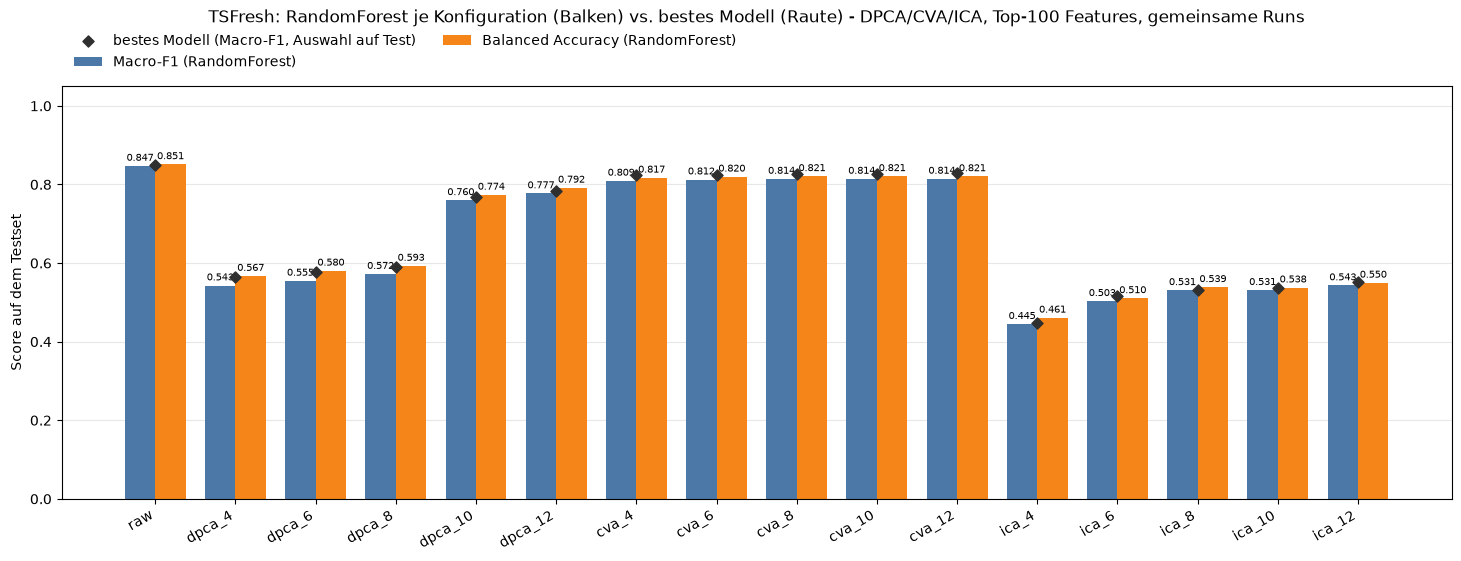

In [11]:
# ============================================================
# Plot: Hauptvergleich (RandomForest) + bestes Modell als Marker
# ============================================================
# Balken = RandomForest (festes Modell -> Konfigurationen fair
# vergleichbar). Rauten = bestes Modell je Konfiguration; dessen Auswahl
# passiert auf dem TESTSET (kein CV in Phase C) und ist daher leicht
# optimistisch - siehe Vergleichszelle.
import matplotlib.pyplot as plt

rf_d = (rf.set_index("Konfiguration").reindex(order)
        if not rf.empty else pd.DataFrame(index=order))
best_d = best_per_config.set_index("Konfiguration").reindex(order)

x = np.arange(len(order))
w = 0.38

fig, ax = plt.subplots(figsize=(14.5, 5.5), constrained_layout=True)

# Blau/Orange: unterscheidet sich auf der Blau-Gelb-Achse, die bei Prot-
# und Deuteranopie erhalten bleibt; Werte stehen zusaetzlich an den Balken.
b1 = ax.bar(x - w / 2, rf_d.get("MacroF1", pd.Series(np.nan, index=order)),
            w, label="Macro-F1 (RandomForest)", color="#4C78A8", zorder=2)
b2 = ax.bar(x + w / 2, rf_d.get("BalancedAcc", pd.Series(np.nan, index=order)),
            w, label="Balanced Accuracy (RandomForest)", color="#F58518",
            zorder=2)
for bars in (b1, b2):
    vals = [b.get_height() for b in bars]
    ax.bar_label(bars, labels=["" if np.isnan(v) else f"{v:.3f}" for v in vals],
                 fontsize=7, padding=2)

# Bestes Modell je Konfiguration als Raute (nur Macro-F1, die Kernzahl).
ax.scatter(x, best_d["MacroF1"], marker="D", s=32, color="#2f2f2f", zorder=3,
           label="bestes Modell (Macro-F1, Auswahl auf Test)")

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylabel("Score auf dem Testset")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.set_axisbelow(True)

# Legende ueber der Achse (3 Eintraege -> 2 Zeilen); pad haelt den Titel
# frei. Im Plot selbst wuerde sie Balken oder Marker verdecken.
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), ncol=2, frameon=False)
ax.set_title(f"TSFresh: RandomForest je Konfiguration (Balken) vs. bestes "
             f"Modell (Raute) - DPCA/CVA/ICA, Top-{TOP_K} Features, "
             f"{'gemeinsame' if RESTRICT_TO_COMMON_RUNS else 'alle'} Runs",
             pad=46)

plt.show()

## Wo weitergemacht werden kann

- **Feature-Namen ansehen:** `top_names["cva_8"]` zeigt, *welche*
  TSFresh-Features eine Konfiguration ausgewählt hat — oft aufschlussreicher
  als der Score. Die vollständige Rangtabelle liefert `rank_features`.
- **Quervergleich mit PCA/DyCA:** `tsfresh_summary.csv` (Schwester-Notebook)
  und `tsfresh_summary_dpca_cva_ica.csv` (dieses Notebook) liegen im selben
  Cache-Ordner und teilen die `raw`-Zeilen als gemeinsamen Anker — beide CSVs
  laden, konkatenieren und über alle 21 Konfigurationen plotten.
- **`TOP_K` variieren:** die Auswahl ist gecacht, ein anderer Wert erzwingt
  eine neue Selektion; die teure Extraktion in `CACHE_DIR` bleibt gültig.
- **CV auch in Phase C:** `LC_CV_FOLDS = 5` verlagert die Modellauswahl vom
  Testset auf Train-CV — kostet ein Mehrfaches der Phase-C-Zeit; die teuren
  Phasen A/B bleiben gecacht.
- **Projektions-Parameter variieren:** `DPCA_LAGS`, `CVA_PAST`/`CVA_FUT`
  oder die FastICA-Einstellungen stehen in der Konfigurationszelle.
  ACHTUNG: die Chunk-Caches der betroffenen Konfigurationen (`dpca_*__...`,
  `cva_*__...`, `ica_*__...`) vorher löschen — der Cache-Name kodiert diese
  Parameter nicht, alte Chunks würden sonst stumm weiterverwendet.
- **Skalierung umstellen:** `SCALING_MODE` in der Konfigurationszelle
  (`"global_mean"` ↔ `"scaler"`); der Cache-Ordner bekommt den Modus
  automatisch angehängt, alte Ergebnisse werden nicht überschrieben.